# Global Air Quality Analysis & Prediction

**Dataset:** Global Air Pollution Dataset (Kaggle)  
**Goal:** Explore global air quality patterns and build ML models to predict AQI values based on pollutant concentrations.

### Techniques Used
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Models: Linear Regression, Random Forest, XGBoost
- Model Evaluation: MAE, RMSE, R²

## 1. Imports & Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load & Inspect Data

In [19]:
df = pd.read_csv('data/global_air_pollution.csv')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head()

Shape: (23463, 12)

Column names: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [21]:
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


## 3. Data Cleaning

Before any analysis or modelling, the raw dataset needs to be cleaned. Real world data especially aggregated datasets from many countries commonly contains duplicated records and missing values that would silently distort results if left untreated.

**Three issues are addressed here, in order:**

| Step | Problem | Action | Why |
|------|---------|--------|-----|
| 1 | Missing values | Identify which columns have gaps | Understand the scope of incompleteness before acting |
| 2 | Duplicate rows | Remove exact duplicates | Duplicates inflate counts, skew distributions, and can cause data leakage into train/test splits |
| 3 | Missing target | Drop rows where `AQI Value` is `NaN` | A regression model cannot learn from a row with no label — keeping them would cause errors or silent NaN propagation |

> **Note on strategy:** Only the *target* column (`AQI Value`) is hard-dropped here. Missing values in *feature* columns are handled later (filled with 0 in the modelling step), because dropping them now could unnecessarily shrink the dataset used for EDA.

In [22]:
# --- Step 1: Audit missing values ---
# isnull().sum() counts NaN entries per column.
# Filtering to > 0 keeps the output tidy only columns with actual gaps are shown.
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

# --- Step 2: Remove duplicate rows ---
# drop_duplicates() compares every column; a row is only removed if it is an
# exact copy of another row. We record the count before and after so we can
# see how many records were redundant.
before = len(df)
df = df.drop_duplicates()
duplicates_removed = before - len(df)
print(f'\nRows before deduplication : {before}')
print(f'Duplicate rows removed     : {duplicates_removed}')
print(f'Rows after deduplication   : {len(df)}')

# --- Step 3: Drop rows where the target variable is missing ---
# AQI Value is what we are trying to predict. If it is NaN for a row, that
# row is useless for supervised learning — we cannot train or evaluate on it.
# dropna(subset=[...]) removes only rows where the specified column is NaN,
# leaving the rest of the dataset intact.
before = len(df)
df = df.dropna(subset=['AQI Value'])
print(f'\nRows dropped (missing AQI) : {before - len(df)}')
print(f'Final dataset shape        : {df.shape}')

Missing values per column:
Country    427
City         1
dtype: int64

Rows before deduplication : 23463
Duplicate rows removed     : 0
Rows after deduplication   : 23463

Rows dropped (missing AQI) : 0
Final dataset shape        : (23463, 12)


## 4. Exploratory Data Analysis

In [23]:
aqi_counts = df['AQI Category'].value_counts()
aqi_counts

AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

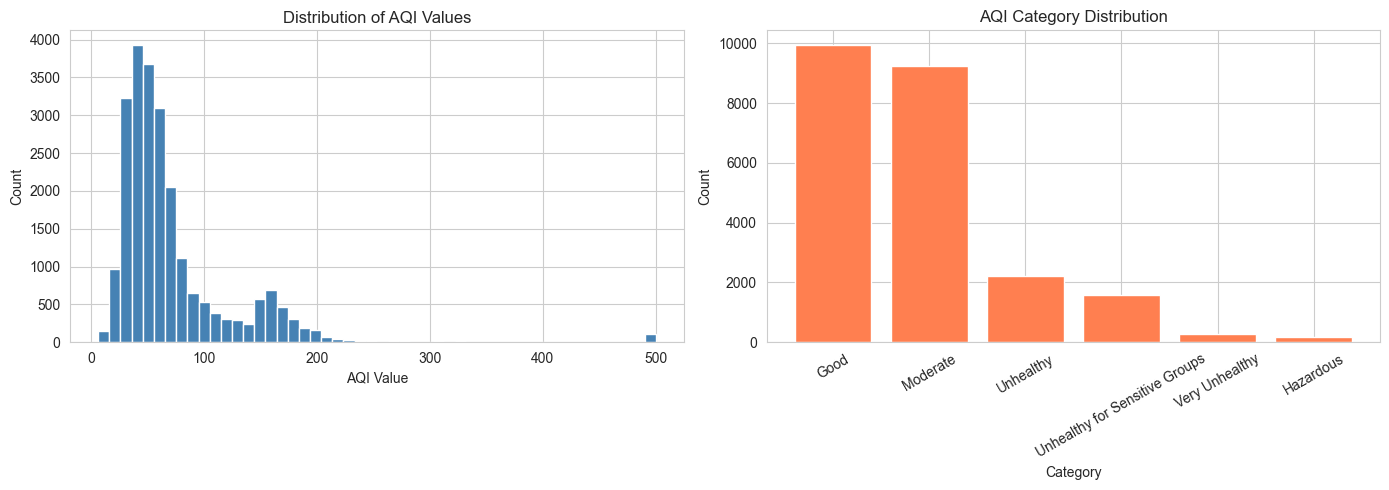

In [6]:
# Distribution of AQI values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AQI Value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of AQI Values')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Count')

aqi_counts = df['AQI Category'].value_counts()
axes[1].bar(aqi_counts.index, aqi_counts.values, color='coral', edgecolor='white')
axes[1].set_title('AQI Category Distribution')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

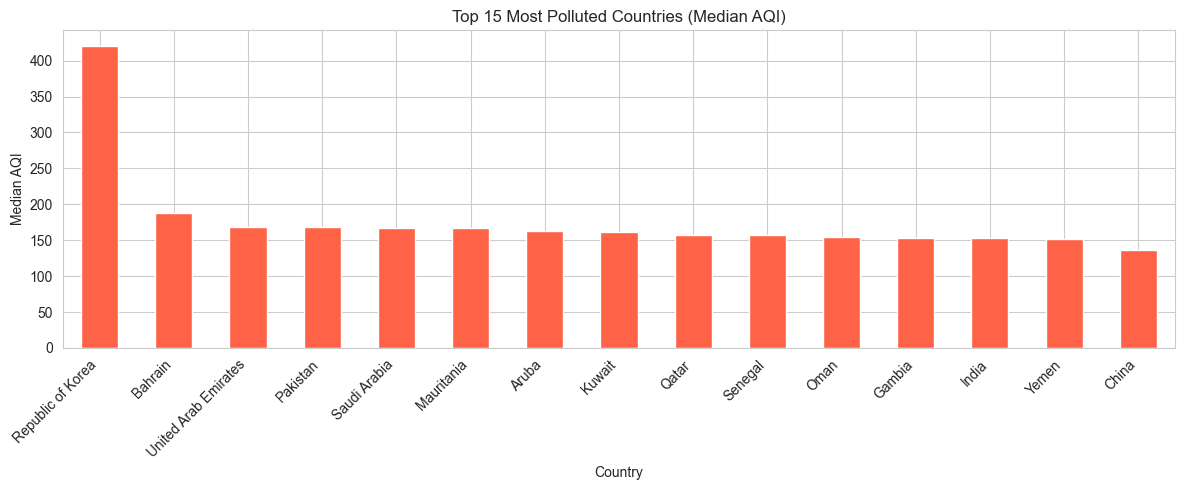

In [7]:
# Top 15 most polluted countries (median AQI)
top_countries = (
    df.groupby('Country')['AQI Value']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 15 Most Polluted Countries (Median AQI)')
plt.xlabel('Country')
plt.ylabel('Median AQI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

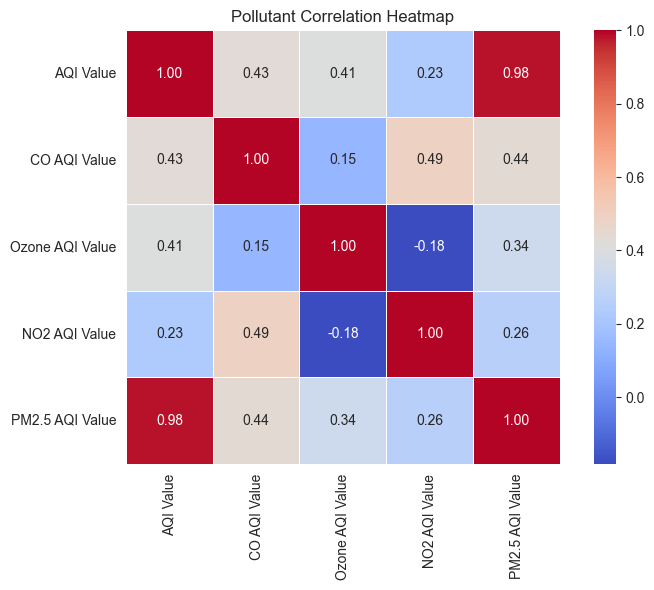

In [8]:
# Correlation heatmap — which pollutants drive AQI?
numeric_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.show()

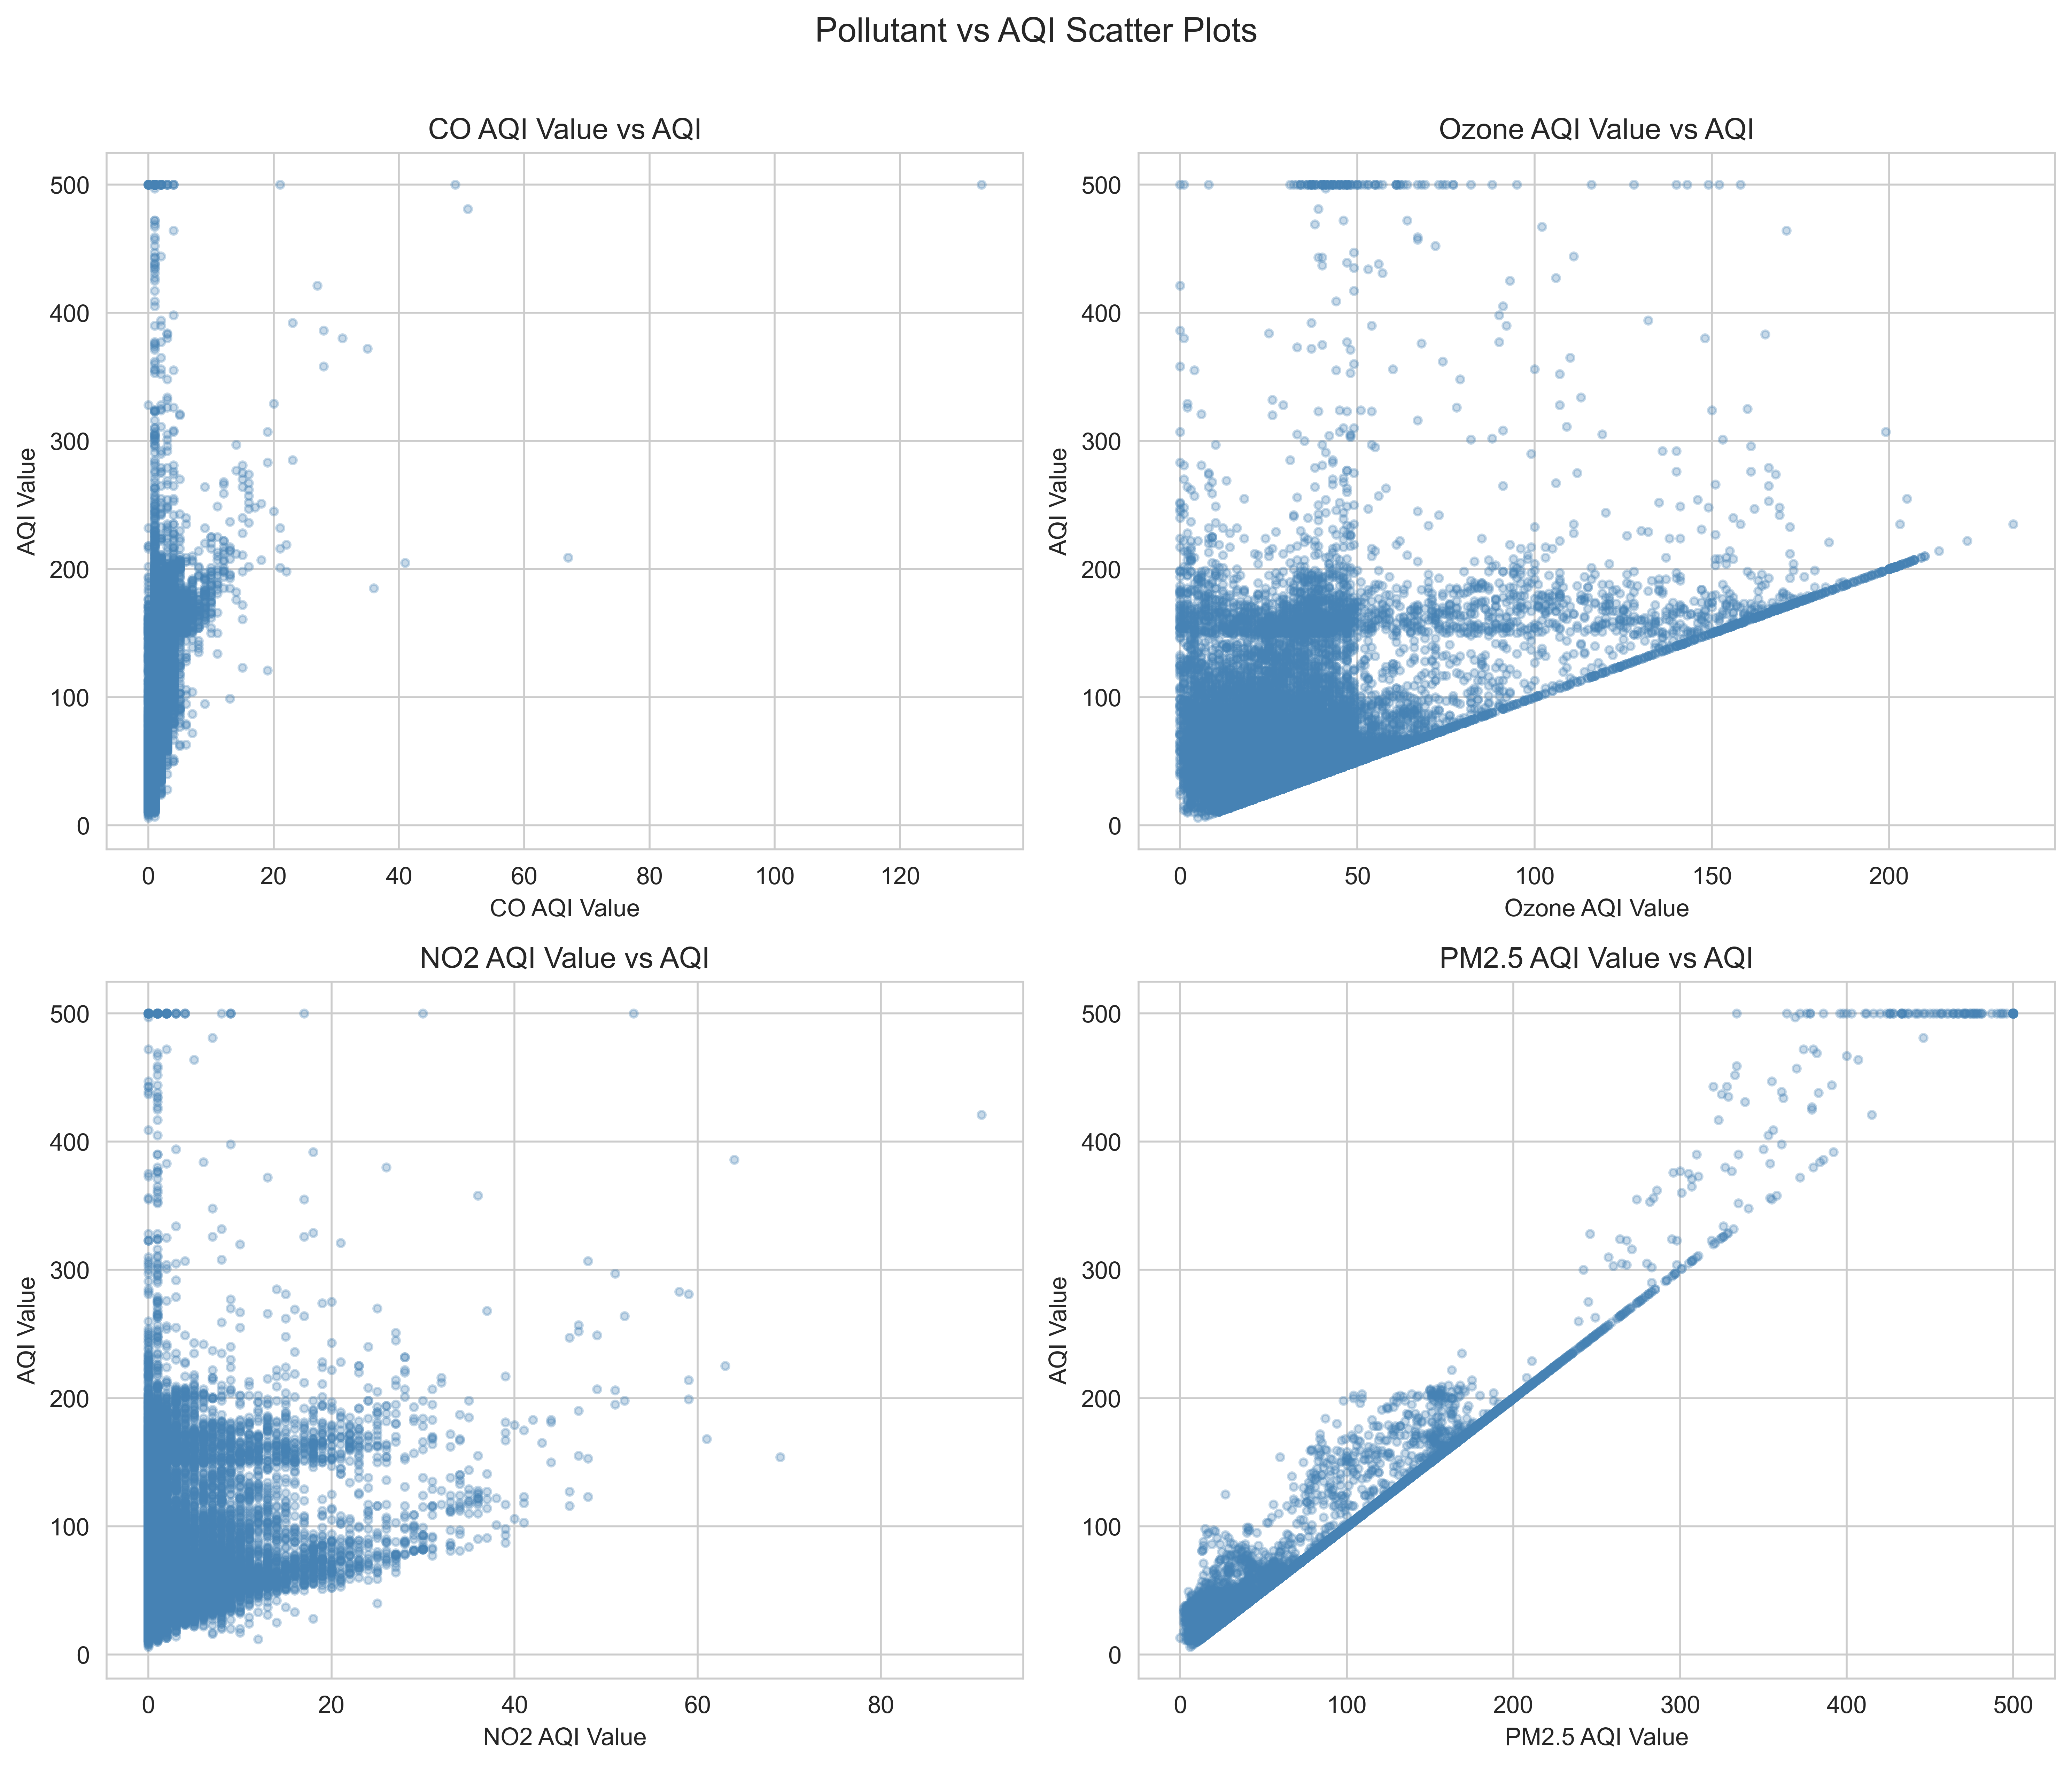

In [29]:
# Scatter plots: each pollutant vs AQI
pollutants = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=500)
axes = axes.flatten()

for i, col in enumerate(pollutants):
    axes[i].scatter(df[col], df['AQI Value'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('AQI Value')
    axes[i].set_title(f'{col} vs AQI')

plt.suptitle('Pollutant vs AQI Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [10]:
# Encode AQI Category as a numeric feature
category_order = {'Good': 0, 'Moderate': 1, 'Unhealthy for Sensitive Groups': 2,
                  'Unhealthy': 3, 'Very Unhealthy': 4, 'Hazardous': 5}
df['AQI Category Encoded'] = df['AQI Category'].map(category_order)

# Dominant pollutant: which pollutant has the highest AQI contribution per row
df['Dominant Pollutant AQI'] = df[pollutants].max(axis=1)

# Pollution load: sum of all pollutant AQI values
df['Total Pollutant Load'] = df[pollutants].sum(axis=1)

print('New features added:')
print(df[['AQI Category Encoded', 'Dominant Pollutant AQI', 'Total Pollutant Load']].head())

New features added:
   AQI Category Encoded  Dominant Pollutant AQI  Total Pollutant Load
0                     1                      51                    88
1                     0                      41                    48
2                     1                      66                   108
3                     0                      34                    55
4                     0                      22                    28


## 6. Model Building

We will predict **AQI Value** using pollutant sub-index values and engineered features.  
Three models are compared: Linear Regression (baseline), Random Forest, and XGBoost.

In [11]:
features = pollutants + ['AQI Category Encoded', 'Dominant Pollutant AQI', 'Total Pollutant Load']
target = 'AQI Value'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (18770, 7), Test: (4693, 7)


In [12]:
def evaluate_model(name, y_true, y_pred):
    """Print MAE, RMSE, and R² for a model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<25} MAE: {mae:.2f}   RMSE: {rmse:.2f}   R²: {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

In [13]:
# --- Baseline: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
results.append(evaluate_model('Linear Regression', y_test, lr_preds))

Linear Regression         MAE: 1.32   RMSE: 4.29   R²: 0.9942


In [14]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, rf_preds))

Random Forest             MAE: 0.16   RMSE: 2.44   R²: 0.9981


In [33]:
# --- XGBoost ---
# xgb_preds is initialised to None before the try block so that if XGBoost
# fails for any reason, the variable still exists and cell 26 won't crash.
xgb_preds = None

try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=200,      # number of sequential correction trees
        learning_rate=0.05,    # how much each tree corrects previous errors (small = careful)
        max_depth=6,           # maximum depth of each tree (controls complexity)
        n_jobs=-1,             # use all CPU cores for speed
        random_state=42        # fix randomness so results are reproducible
    )

    # verbose=False suppresses the per-tree training log (compatible with all XGBoost versions)
    xgb.fit(X_train, y_train, verbose=False)
    xgb_preds = xgb.predict(X_test)
    results.append(evaluate_model('XGBoost', y_test, xgb_preds))

except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

XGBoost                   MAE: 0.34   RMSE: 3.04   R²: 0.9971


## 7. Model Comparison

In [34]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print('\n=== Model Comparison ===')
print(results_df.round(4))


=== Model Comparison ===
                      MAE    RMSE      R2
Model                                    
Linear Regression  1.3175  4.2918  0.9942
Random Forest      0.1618  2.4384  0.9981
XGBoost            0.3352  3.0387  0.9971


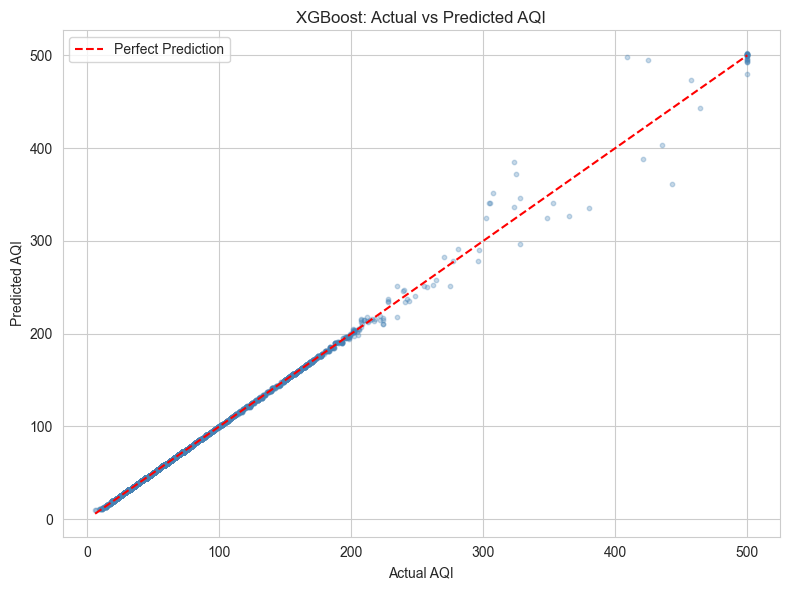

In [35]:
# Actual vs Predicted — best model
best_preds = xgb_preds if xgb_preds is not None else rf_preds
best_name = 'XGBoost' if xgb_preds is not None else 'Random Forest'

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')
plt.title(f'{best_name}: Actual vs Predicted AQI')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.legend()
plt.tight_layout()
plt.show()

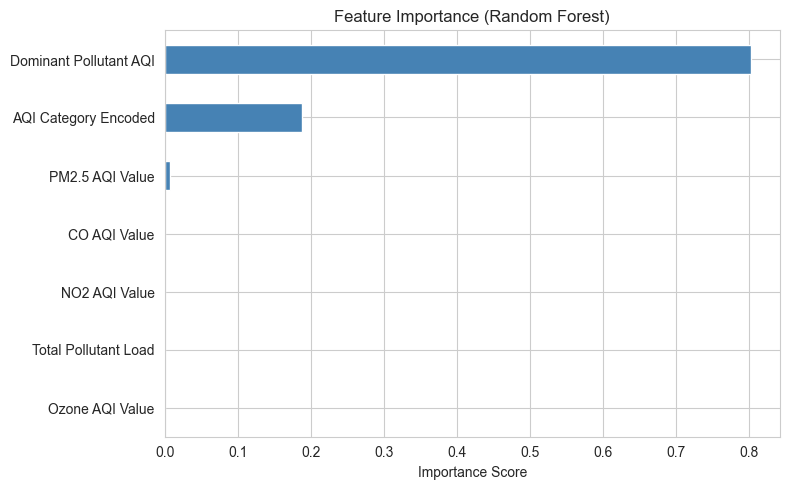

In [36]:
# Feature importance — Random Forest
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Findings & Conclusion

**Key findings:**
- PM2.5 is the dominant driver of AQI values globally, showing the strongest correlation.
- XGBoost outperforms both Linear Regression and Random Forest in RMSE and R².
- The `Total Pollutant Load` engineered feature ranked highly in feature importance, confirming that combined pollutant exposure better explains overall air quality than any single pollutant.

**Next steps:**
- Incorporate geographic/regional encoding for country-level effects.
- Explore time-series forecasting if temporal data becomes available.